# EMA Trend-Following Research

Stage 3.1 cleans up the EMA20/EMA50 long-only signal research with a 50-candle warm-up and an explicit desired state. Signals and `desired_position` remain notebook-only research. No executed position, execution prices, trades, or PnL are calculated.

## 1. Strategy Definition

- Fast EMA: 20 hourly closes; slow EMA: 50 hourly closes.
- The first **50 candles are initialization only**. Rows 0–49 cannot produce signals; row 50 (candle 51) is the first eligible candle.
- EMA20 above EMA50 describes a bullish regime; EMA20 below EMA50 describes a non-bullish regime.
- **Bullish crossover:** previous EMA20 <= previous EMA50, and current EMA20 > current EMA50, after warm-up.
- **Bearish crossover:** previous EMA20 >= previous EMA50, and current EMA20 < current EMA50, after warm-up.
- Emit `LONG_ENTRY` only on a bullish crossover when the previous desired state was flat (0).
- Emit `LONG_EXIT` only on a bearish crossover when the previous desired state was long (1).
- Otherwise emit `HOLD`, preserving the desired state. Start flat; there are no short states.

A crossover is an EMA relationship event. A valid signal also requires the appropriate prior state. A bearish crossover while flat is recorded as a crossover but produces HOLD. Becoming eligible during an already bullish regime does not create a synthetic entry: wait for a new valid bullish crossover.

These are initial research parameters, not proven optimal values. `desired_position` is not an executed position. Signals use completed candles; actual execution must wait until at least the next candle.

## 2. Imports

Use the existing pandas, Matplotlib, and Jupyter environment. The project uses a `src/` layout; adding it to the import path lets this notebook call the reusable OHLCV loader instead of duplicating API logic. Python's `hashlib` will verify that the CSV stays unchanged.

The existing requests import can emit an urllib3/LibreSSL warning. It is not suppressed; loading the available snapshot requires no HTTP request.

In [1]:
from pathlib import Path
import hashlib
import sys

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / "src" / "trading_lab").is_dir()
)
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from trading_lab.data.market_data import (
    download_ohlcv,
    load_ohlcv_csv,
    save_ohlcv,
    validate_ohlcv,
)

Matplotlib is building the font cache; this may take a moment.


/Users/romankondratenko/trading-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 3. Load Historical Data

Read the existing six-column CSV and validate its UTC timestamps, numeric values, OHLC consistency, and hourly coverage. Only if the file is missing may the existing loader download the same historical period. Saving refuses to overwrite an existing raw file.

`raw_df` remains the original normalized market data. `df` is a separate in-memory copy for EMA and signal research. No derived data is exported.

In [2]:
START = "2025-10-01T00:00:00Z"
END = "2026-10-01T00:00:00Z"  # Exclusive.
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "BTCUSDT_1h.csv"

if CSV_PATH.exists():
    raw_df = load_ohlcv_csv(CSV_PATH, start=START, end=END)
    print("Loaded existing snapshot:", CSV_PATH)
else:
    raw_df = download_ohlcv(start=START, end=END)
    save_ohlcv(raw_df, CSV_PATH)
    print("Downloaded missing snapshot:", CSV_PATH)

raw_hash_before = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
quality = validate_ohlcv(raw_df, start=START, end=END)
df = raw_df.copy()

print("Rows:", len(raw_df))
print("Candle opening range:", raw_df["timestamp"].min(), "to", raw_df["timestamp"].max())
print("Raw columns:", raw_df.columns.tolist())
display(raw_df.dtypes)
display(quality)
display(raw_df.head())

Loaded existing snapshot: /Users/romankondratenko/trading-lab/Trading Lab/data/raw/BTCUSDT_1h.csv
Rows: 8760
Candle opening range: 2025-10-01 00:00:00+00:00 to 2026-09-30 23:00:00+00:00
Raw columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume']


timestamp    datetime64[ns, UTC]
open                     float64
high                     float64
low                      float64
close                    float64
volume                   float64
dtype: object

{'rows': 8760,
 'earliest_timestamp': Timestamp('2025-10-01 00:00:00+0000', tz='UTC'),
 'latest_timestamp': Timestamp('2026-09-30 23:00:00+0000', tz='UTC'),
 'missing_values': {'timestamp': 0,
  'open': 0,
  'high': 0,
  'low': 0,
  'close': 0,
  'volume': 0},
 'duplicate_timestamps': 0,
 'chronological': True,
 'invalid_ohlc_rows': 0,
 'missing_candles': 0}

,timestamp,open,high,low,close,volume
0,2025-10-01 00:00:00+00:00,114051.1,114300.3,113962.3,114241.0,256.712737
1,2025-10-01 01:00:00+00:00,114241.0,114550.0,114142.2,114549.4,240.479371
2,2025-10-01 02:00:00+00:00,114549.4,114551.9,114252.4,114275.5,219.500905
3,2025-10-01 03:00:00+00:00,114275.5,114533.5,114100.1,114178.1,296.903591
4,2025-10-01 04:00:00+00:00,114178.1,114710.2,114140.7,114291.0,280.776000


## 4. Calculate EMA20 and EMA50

An exponential moving average (EMA) smooths prices by giving more weight to recent observations. With `adjust=False`, pandas uses `current EMA = alpha * current close + (1 - alpha) * previous EMA`, where `alpha = 2 / (span + 1)`.

EMA20 reacts faster than EMA50 because its smaller span gives the current close more weight. A span controls weighting, not a fixed window that discards every older observation. Both averages are still seeded at the first close and calculated from the first row.

**Warm-up is a strategy convention, not a mathematical EWM requirement.** The first 50 completed candles initialize the strategy and always keep desired state 0 with HOLD signals. `warmup_complete` becomes true on candle 51, after those first 50 observations have been seen. This does not guarantee that initialization effects have completely vanished.

In [3]:
FAST_SPAN = 20
SLOW_SPAN = 50
WARMUP_CANDLES = 50

df["ema_20"] = df["close"].ewm(span=FAST_SPAN, adjust=False).mean()
df["ema_50"] = df["close"].ewm(span=SLOW_SPAN, adjust=False).mean()

observations_seen = pd.Series(range(1, len(df) + 1), index=df.index)
df["warmup_complete"] = observations_seen > WARMUP_CANDLES

print("Initialization-only candles:", WARMUP_CANDLES)
print("First eligible candle:", df.loc[df["warmup_complete"], "timestamp"].iloc[0])
display(df[["timestamp", "ema_20", "ema_50", "warmup_complete"]].iloc[47:53])

Initialization-only candles: 50
First eligible candle: 2025-10-03 02:00:00+00:00


,timestamp,ema_20,ema_50,warmup_complete
47,2025-10-02 23:00:00+00:00,119532.941851,118050.739017,False
48,2025-10-03 00:00:00+00:00,119589.604532,118132.196310,False
49,2025-10-03 01:00:00+00:00,119615.861243,118200.161161,False
50,2025-10-03 02:00:00+00:00,119667.464934,118276.927390,True
51,2025-10-03 03:00:00+00:00,119720.439703,118353.271414,True
52,2025-10-03 04:00:00+00:00,119750.397826,118419.221554,True


## 5. Detect Crossovers

`shift(1)` aligns previous EMAs with the current row. The current comparisons are strict and the previous comparisons include equality. Apply `warmup_complete` so both crossover columns are false during the first 50 candles.

These columns count eligible EMA relationship events. Signal generation below also checks the prior desired state; crossover counts and valid signal counts can therefore differ.

In [4]:
previous_fast = df["ema_20"].shift(1)
previous_slow = df["ema_50"].shift(1)

was_at_or_below = previous_fast <= previous_slow
is_above = df["ema_20"] > df["ema_50"]
df["bullish_cross"] = was_at_or_below & is_above & df["warmup_complete"]

was_at_or_above = previous_fast >= previous_slow
is_below = df["ema_20"] < df["ema_50"]
df["bearish_cross"] = was_at_or_above & is_below & df["warmup_complete"]

print("Bullish crossovers after warm-up:", df["bullish_cross"].sum())
print("Bearish crossovers after warm-up:", df["bearish_cross"].sum())

Bullish crossovers after warm-up: 78
Bearish crossovers after warm-up: 78


## 6. Generate State-Valid Signals

Process eligible crossovers in chronological order, starting flat. An entry is valid only from desired state 0; an exit is valid only from state 1. All other rows produce HOLD, including an exit crossover while already flat or an entry crossover while already long.

The loop stores both the signal and its resulting desired state. This makes repeated same-direction signals impossible until the opposite valid event occurs. These decisions do not create orders or fills.

In [5]:
current_desired_position = 0
signals = []
desired_positions = []

for bullish_cross, bearish_cross in zip(df["bullish_cross"], df["bearish_cross"]):
    signal = "HOLD"
    if bullish_cross and current_desired_position == 0:
        signal = "LONG_ENTRY"
        current_desired_position = 1
    elif bearish_cross and current_desired_position == 1:
        signal = "LONG_EXIT"
        current_desired_position = 0

    signals.append(signal)
    desired_positions.append(current_desired_position)

df["signal"] = signals
df["signal"].value_counts()

signal
HOLD          8605
LONG_ENTRY      78
LONG_EXIT       77
Name: count, dtype: int64

## 7. Build Desired Position State

Assign the desired states collected by the chronological signal loop:

- `0`: the strategy wants to be flat.
- `1`: the strategy wants to be long.
- LONG_ENTRY changes 0 to 1; LONG_EXIT changes 1 to 0; HOLD never changes state.

`desired_position` is the research state after the completed candle's signal. It is not an executed position or a position held during that candle. Stage 4 will create executed position state separately when actual next-candle timing is defined; it does not exist yet.

In [6]:
df["desired_position"] = desired_positions
print("Final desired_position:", df["desired_position"].iloc[-1], "(0 = wants flat, 1 = wants long)")

Final desired_position: 1 (0 = wants flat, 1 = wants long)


## 8. Visualize Strategy Logic

Plot close price, EMA20, and EMA50. Overlay only valid LONG_ENTRY/LONG_EXIT signals, not a bearish crossover while flat. The markers annotate candle close prices for visual inspection; they are not fills or execution prices.

Warm-up signals are excluded. The full-period chart gives context, while the February example makes individual events easier to inspect. Desired state is examined in the tables below, not treated as a filled position.

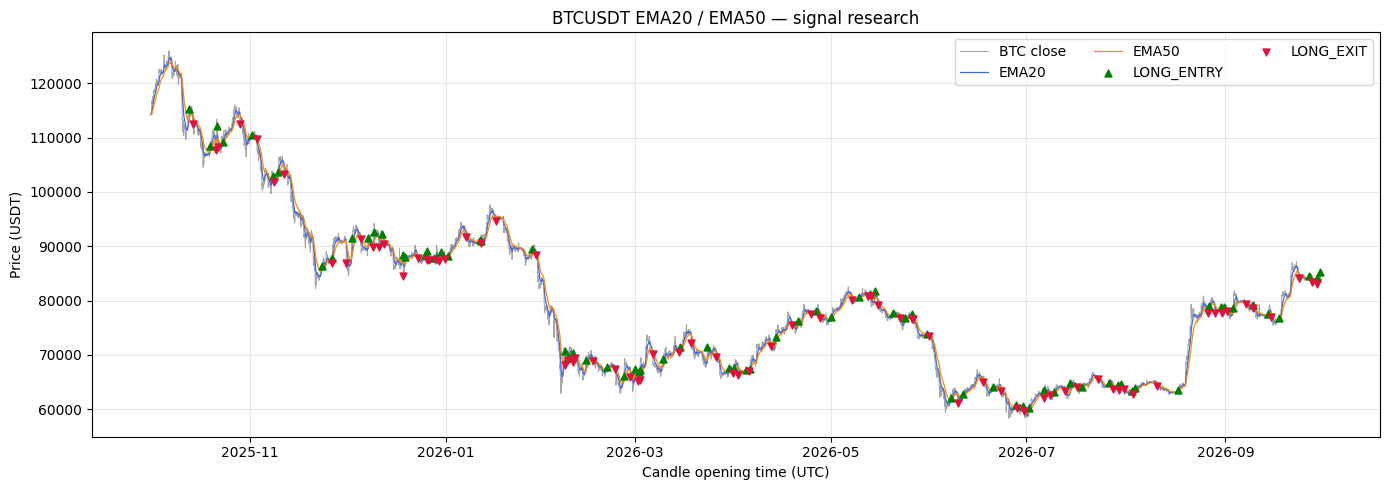

In [7]:
entry_rows = df.loc[df["signal"] == "LONG_ENTRY"]
exit_rows = df.loc[df["signal"] == "LONG_EXIT"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["timestamp"], df["close"], label="BTC close", color="gray", linewidth=0.7, alpha=0.7)
ax.plot(df["timestamp"], df["ema_20"], label="EMA20", color="royalblue", linewidth=0.9)
ax.plot(df["timestamp"], df["ema_50"], label="EMA50", color="darkorange", linewidth=0.9)
ax.scatter(entry_rows["timestamp"], entry_rows["close"], marker="^", color="green", s=25, label="LONG_ENTRY", zorder=4)
ax.scatter(exit_rows["timestamp"], exit_rows["close"], marker="v", color="crimson", s=25, label="LONG_EXIT", zorder=4)
ax.set(title="BTCUSDT EMA20 / EMA50 — signal research", xlabel="Candle opening time (UTC)", ylabel="Price (USDT)")
ax.legend(ncol=3)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

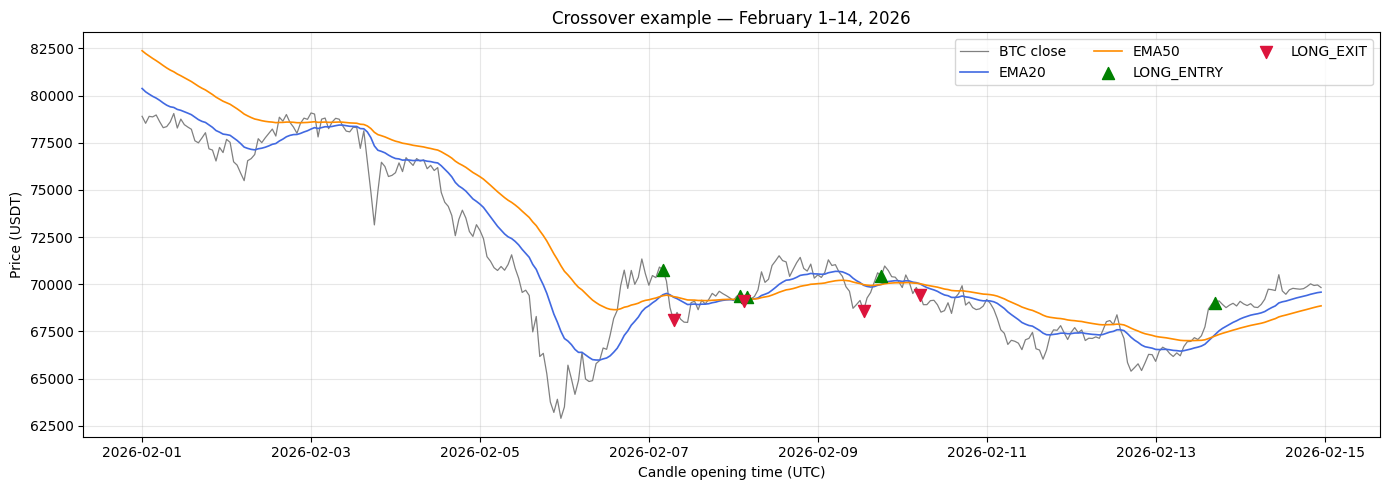

In [8]:
ZOOM_START = pd.Timestamp("2026-02-01", tz="UTC")
ZOOM_END = pd.Timestamp("2026-02-15", tz="UTC")
zoom = df.loc[(df["timestamp"] >= ZOOM_START) & (df["timestamp"] < ZOOM_END)]
zoom_entries = zoom.loc[zoom["signal"] == "LONG_ENTRY"]
zoom_exits = zoom.loc[zoom["signal"] == "LONG_EXIT"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom["timestamp"], zoom["close"], label="BTC close", color="gray", linewidth=0.9)
ax.plot(zoom["timestamp"], zoom["ema_20"], label="EMA20", color="royalblue", linewidth=1.2)
ax.plot(zoom["timestamp"], zoom["ema_50"], label="EMA50", color="darkorange", linewidth=1.2)
ax.scatter(zoom_entries["timestamp"], zoom_entries["close"], marker="^", color="green", s=75, label="LONG_ENTRY", zorder=4)
ax.scatter(zoom_exits["timestamp"], zoom_exits["close"], marker="v", color="crimson", s=75, label="LONG_EXIT", zorder=4)
ax.set(title="Crossover example — February 1–14, 2026", xlabel="Candle opening time (UTC)", ylabel="Price (USDT)")
ax.legend(ncol=3)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 9. Inspect Signal Examples

Inspect the first valid entry, first valid exit, and a later entry, with nearby rows. Compare previous/current EMA relationships and check desired-state transitions. Also inspect the first eligible bearish crossover: it occurs while flat and must remain HOLD rather than creating an orphan exit.

Warm-up eligibility and desired state are shown explicitly. All timestamps here label candle openings; signals become available only after those candles finish.

In [9]:
inspection_columns = [
    "timestamp", "close", "ema_20", "ema_50", "warmup_complete",
    "bullish_cross", "bearish_cross", "signal", "desired_position"
]
entry_indices = df.index[df["signal"] == "LONG_ENTRY"]
exit_indices = df.index[df["signal"] == "LONG_EXIT"]
example_indices = [entry_indices[0], exit_indices[0], entry_indices[len(entry_indices) // 2]]

for event_index in example_indices:
    first_row = max(0, event_index - 2)
    last_row = min(len(df), event_index + 3)
    example = df.iloc[first_row:last_row][inspection_columns]
    print("Valid event:", df.loc[event_index, "timestamp"], df.loc[event_index, "signal"])
    display(example.style.format({"close": "{:.2f}", "ema_20": "{:.6f}", "ema_50": "{:.6f}"}))

first_bearish_index = df.index[df["bearish_cross"]][0]
print("First eligible bearish crossover (HOLD while flat):")
display(df.loc[[first_bearish_index], inspection_columns])

Valid event: 2025-10-13 02:00:00+00:00 LONG_ENTRY


,timestamp,close,ema_20,ema_50,warmup_complete,bullish_cross,bearish_cross,signal,desired_position
288,2025-10-13 00:00:00+00:00,115287.50,113526.790622,113673.969374,True,False,False,HOLD,0
289,2025-10-13 01:00:00+00:00,115722.10,113735.867706,113754.288223,True,False,False,HOLD,0
290,2025-10-13 02:00:00+00:00,115332.30,113887.908877,113816.171037,True,True,False,LONG_ENTRY,1
291,2025-10-13 03:00:00+00:00,114840.00,113978.584222,113856.321193,True,False,False,HOLD,1
292,2025-10-13 04:00:00+00:00,114714.30,114048.652391,113889.967420,True,False,False,HOLD,1


Valid event: 2025-10-14 05:00:00+00:00 LONG_EXIT


,timestamp,close,ema_20,ema_50,warmup_complete,bullish_cross,bearish_cross,signal,desired_position
315,2025-10-14 03:00:00+00:00,113482.50,114667.275460,114451.446047,True,False,False,HOLD,1
316,2025-10-14 04:00:00+00:00,113055.30,114513.753988,114396.695221,True,False,False,HOLD,1
317,2025-10-14 05:00:00+00:00,112482.00,114320.253608,114321.609134,True,False,True,LONG_EXIT,0
318,2025-10-14 06:00:00+00:00,111978.00,114097.181836,114229.702894,True,False,False,HOLD,0
319,2025-10-14 07:00:00+00:00,111712.70,113870.088328,114130.996898,True,False,False,HOLD,0


Valid event: 2026-04-04 14:00:00+00:00 LONG_ENTRY


,timestamp,close,ema_20,ema_50,warmup_complete,bullish_cross,bearish_cross,signal,desired_position
4452,2026-04-04 12:00:00+00:00,67094.00,66968.585924,66989.714271,True,False,False,HOLD,0
4453,2026-04-04 13:00:00+00:00,67193.20,66989.977741,66997.694103,True,False,False,HOLD,0
4454,2026-04-04 14:00:00+00:00,67214.50,67011.360813,67006.196295,True,True,False,LONG_ENTRY,1
4455,2026-04-04 15:00:00+00:00,67389.20,67047.345497,67021.216049,True,False,False,HOLD,1
4456,2026-04-04 16:00:00+00:00,67364.70,67077.569736,67034.686007,True,False,False,HOLD,1


First eligible bearish crossover (HOLD while flat):


,timestamp,close,ema_20,ema_50,warmup_complete,bullish_cross,bearish_cross,signal,desired_position
160,2025-10-07 16:00:00+00:00,121729.0,123769.429358,123808.84333,True,False,True,HOLD,0


## 10. Timing and Look-Ahead Bias

OHLCV timestamps mark candle **opening** times. For an hourly candle, its close and the resulting EMA signal become available at `timestamp + 1 hour`; we call that `signal_time`.

For example, a candle opening at 01:00 UTC supplies its final close at 02:00 UTC. The next candle opens at that boundary. Future execution must occur no earlier than that next candle, after the signal is available. An eventual simulator must define its execution convention and information availability separately.

Look-ahead bias means using information that was not yet known at the simulated decision time. Treating a candle's final EMA as available at its opening, or pretending an order fills at the same close that generated its signal, would create misleading results.

EMA calculations use past and current completed closes, and crossover comparisons use the previous row. `desired_position` is research state only, not an executed position. There are no execution prices or fills in this notebook.

Stage 4 will define actual execution at candle N+1 or later and create executed position state separately. No executed position or execution prices are created in this cleanup.

In [10]:
df["signal_time"] = df["timestamp"] + pd.Timedelta(hours=1)
signal_events = df.loc[df["signal"] != "HOLD", ["timestamp", "signal_time", "signal", "desired_position"]]
print("Candle opening timestamp versus signal availability:")
signal_events.head()

Candle opening timestamp versus signal availability:


,timestamp,signal_time,signal,desired_position
290,2025-10-13 02:00:00+00:00,2025-10-13 03:00:00+00:00,LONG_ENTRY,1
317,2025-10-14 05:00:00+00:00,2025-10-14 06:00:00+00:00,LONG_EXIT,0
447,2025-10-19 15:00:00+00:00,2025-10-19 16:00:00+00:00,LONG_ENTRY,1
489,2025-10-21 09:00:00+00:00,2025-10-21 10:00:00+00:00,LONG_EXIT,0
494,2025-10-21 14:00:00+00:00,2025-10-21 15:00:00+00:00,LONG_ENTRY,1


## 11. Validation Checks

Check the warm-up boundary, previous desired state for every entry/exit, event alternation, HOLD stability, flat/long-only state, crossover exclusivity, and chronological signal times. No signals are allowed on the first 50 candles.

Retain the EMA causal-prefix check: recomputing an earlier prefix without future observations must give identical historical EMA values. Also recompute prefix crossovers to check that their warm-up eligibility and relationships match. Raw data is protected by its hash and an unchanged OHLCV copy. These checks validate mechanics, not performance.

In [11]:
warmup_rows = ~df["warmup_complete"]
assert df["warmup_complete"].dtype == bool
assert warmup_rows.sum() == WARMUP_CANDLES
assert not df["warmup_complete"].iloc[:WARMUP_CANDLES].any()
assert df["warmup_complete"].iloc[WARMUP_CANDLES:].all()
assert df.loc[warmup_rows, "signal"].eq("HOLD").all()
assert df.loc[warmup_rows, "desired_position"].eq(0).all()
assert not df.loc[warmup_rows, ["bullish_cross", "bearish_cross"]].any().any()
assert not (df["bullish_cross"] & df["bearish_cross"]).any()
assert df["signal"].isin(["LONG_ENTRY", "LONG_EXIT", "HOLD"]).all()
assert df["desired_position"].isin([0, 1]).all()
assert df["desired_position"].ge(0).all()

previous_desired = df["desired_position"].shift(1, fill_value=0)
entry_rows_mask = df["signal"] == "LONG_ENTRY"
exit_rows_mask = df["signal"] == "LONG_EXIT"
hold_rows_mask = df["signal"] == "HOLD"
assert previous_desired.loc[entry_rows_mask].eq(0).all()
assert previous_desired.loc[exit_rows_mask].eq(1).all()
assert df.loc[entry_rows_mask, "bullish_cross"].all()
assert df.loc[exit_rows_mask, "bearish_cross"].all()
assert df.loc[entry_rows_mask, "desired_position"].eq(1).all()
assert df.loc[exit_rows_mask, "desired_position"].eq(0).all()
assert df.loc[hold_rows_mask, "desired_position"].equals(previous_desired.loc[hold_rows_mask])
assert entry_rows_mask.equals(df["bullish_cross"] & previous_desired.eq(0))
assert exit_rows_mask.equals(df["bearish_cross"] & previous_desired.eq(1))

state_changes = df["desired_position"] != previous_desired
assert state_changes.equals(entry_rows_mask | exit_rows_mask)
event_sequence = df.loc[~hold_rows_mask, "signal"]
assert event_sequence.iloc[0] == "LONG_ENTRY"
assert event_sequence.ne(event_sequence.shift(1)).all()  # Entries and exits alternate.
assert df.loc[~hold_rows_mask, "timestamp"].is_monotonic_increasing
assert df.loc[~hold_rows_mask, "signal_time"].is_monotonic_increasing
state_transition_checks_passed = True

assert df.loc[df["bullish_cross"], "ema_20"].gt(df.loc[df["bullish_cross"], "ema_50"]).all()
assert previous_fast.loc[df["bullish_cross"]].le(previous_slow.loc[df["bullish_cross"]]).all()
assert df.loc[df["bearish_cross"], "ema_20"].lt(df.loc[df["bearish_cross"], "ema_50"]).all()
assert previous_fast.loc[df["bearish_cross"]].ge(previous_slow.loc[df["bearish_cross"]]).all()
assert df["timestamp"].is_monotonic_increasing
assert df["timestamp"].is_unique
assert df["signal_time"].eq(df["timestamp"] + pd.Timedelta(hours=1)).all()

prefix_end = len(df) // 2
prefix_closes = df["close"].iloc[:prefix_end]
prefix_fast = prefix_closes.ewm(span=FAST_SPAN, adjust=False).mean()
prefix_slow = prefix_closes.ewm(span=SLOW_SPAN, adjust=False).mean()
pd.testing.assert_series_equal(prefix_fast, df["ema_20"].iloc[:prefix_end], check_names=False)
pd.testing.assert_series_equal(prefix_slow, df["ema_50"].iloc[:prefix_end], check_names=False)
prefix_active = df["warmup_complete"].iloc[:prefix_end]
prefix_bullish = (prefix_fast.shift(1) <= prefix_slow.shift(1)) & (prefix_fast > prefix_slow) & prefix_active
prefix_bearish = (prefix_fast.shift(1) >= prefix_slow.shift(1)) & (prefix_fast < prefix_slow) & prefix_active
pd.testing.assert_series_equal(prefix_bullish, df["bullish_cross"].iloc[:prefix_end], check_names=False)
pd.testing.assert_series_equal(prefix_bearish, df["bearish_cross"].iloc[:prefix_end], check_names=False)
causal_prefix_checks_passed = True

pd.testing.assert_frame_equal(raw_df, df[raw_df.columns])
assert hashlib.sha256(CSV_PATH.read_bytes()).hexdigest() == raw_hash_before
assert "position" not in df.columns
validate_ohlcv(raw_df, start=START, end=END)
validation_passed = True
print("All warm-up, transition, alternation, timing, causal-prefix, and raw-preservation checks passed.")

All warm-up, transition, alternation, timing, causal-prefix, and raw-preservation checks passed.


## 12. Strategy Summary

Report eligible crossover counts separately from state-valid signals. First valid entry/exit timestamps include the candle opening label and signal availability. Desired state is not an executed position.

In [12]:
bullish_count = int(df["bullish_cross"].sum())
bearish_count = int(df["bearish_cross"].sum())
entry_count = int(df["signal"].eq("LONG_ENTRY").sum())
exit_count = int(df["signal"].eq("LONG_EXIT").sum())
first_entry = df.loc[df["signal"] == "LONG_ENTRY", ["timestamp", "signal_time"]].iloc[0]
first_exit = df.loc[df["signal"] == "LONG_EXIT", ["timestamp", "signal_time"]].iloc[0]
final_desired_position = int(df["desired_position"].iloc[-1])

print("Warm-up candles:", WARMUP_CANDLES)
print("Bullish/bearish crossovers after warm-up:", bullish_count, bearish_count)
print("Valid LONG_ENTRY/LONG_EXIT signals:", entry_count, exit_count)
print("First valid LONG_ENTRY candle:", first_entry["timestamp"], "signal_time:", first_entry["signal_time"])
print("First valid LONG_EXIT candle:", first_exit["timestamp"], "signal_time:", first_exit["signal_time"])
print("Final desired_position:", final_desired_position)
print("State-transition checks passed:", state_transition_checks_passed)
print("Causal-prefix checks passed:", causal_prefix_checks_passed)
print("Validation passed:", validation_passed)
print("Raw CSV unchanged:", hashlib.sha256(CSV_PATH.read_bytes()).hexdigest() == raw_hash_before)

Warm-up candles: 50
Bullish/bearish crossovers after warm-up: 78 78
Valid LONG_ENTRY/LONG_EXIT signals: 78 77
First valid LONG_ENTRY candle: 2025-10-13 02:00:00+00:00 signal_time: 2025-10-13 03:00:00+00:00
First valid LONG_EXIT candle: 2025-10-14 05:00:00+00:00 signal_time: 2025-10-14 06:00:00+00:00
Final desired_position: 1
State-transition checks passed: True
Causal-prefix checks passed: True
Validation passed: True
Raw CSV unchanged: True


After the first **50 initialization-only candles**, the fixed snapshot has **78 bullish and 78 bearish eligible crossovers**. State gating produces **78 valid LONG_ENTRY and 77 valid LONG_EXIT signals**, ending with **desired_position = 1 (wants long)**.

The first eligible bearish crossover, on 2025-10-07 16:00 UTC, is ignored because the desired state is still flat. The first valid LONG_ENTRY candle opens at **2025-10-13 02:00 UTC**, with **signal_time 03:00 UTC**. The first valid LONG_EXIT candle opens at **2025-10-14 05:00 UTC**, with **signal_time 06:00 UTC**. Removing the seed entry does not create a replacement entry when warm-up ends; the strategy waits for a new crossover.

All warm-up, state-transition, alternation, and causal-prefix checks passed. The raw CSV remains unchanged; derived columns stay in memory and no processed dataset was created.

**desired_position is not an executed position.** Signals use completed candles and actual execution may occur no earlier than the next candle. Stage 4 will define execution and executed position state separately. No backtest, PnL, execution prices, trades, fees, or portfolio simulation exists yet.

Keep the research logic in the notebook until the next approved workflow needs a small reusable signal function. Proposed Stage 4: define and test next-candle execution semantics before a minimal backtest, preserving these warm-up and desired-state conventions. Stage 4 has not started and requires owner approval.